In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
# input_file = "/data/elugos/event_embedding/train_20251214.csv"
input_file = "../data/train_20251214.csv"
df = pd.read_csv(input_file)

/tmp/ipykernel_4814/814563990.py:3: DtypeWarning: Columns (41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


In [99]:
df.head()

,level_0,index,GlobalEventID,date,Year,Actor1Code,Actor1Name,Actor1CountryCode,Actor1EthnicCode,Actor2Code,...,target,title,text,description,sbert_text_title,embedding_json_title,sbert_text,embedding_json,first_para,first_para_emb
0,0,0,1200203233,20240918,2024,USA,UNITED STATES,USA,NaN,CRM,...,bostonherald,Tren de Aragua gang started in Venezuela’s pri...,MIAMI (AP) — Former federal agent Was Tabor sa...,The gang has exploded into the presidential ca...,Tren de Aragua gang started in Venezuela’s pri...,"[-0.002818030072376132, -0.01742059737443924, ...",NaN,NaN,MIAMI (AP) — Former federal agent Was Tabor sa...,"[-0.08164523541927338, -0.027655698359012604, ..."
1,1,1,1200203234,20240918,2024,USA,FLORIDA,USA,NaN,GOV,...,bostonherald,Tren de Aragua gang started in Venezuela’s pri...,MIAMI (AP) — Former federal agent Was Tabor sa...,The gang has exploded into the presidential ca...,Tren de Aragua gang started in Venezuela’s pri...,"[-0.002818030072376132, -0.01742059737443924, ...",NaN,NaN,MIAMI (AP) — Former federal agent Was Tabor sa...,"[-0.08164523541927338, -0.027655698359012604, ..."
2,2,2,1200203284,20240925,2024,NaN,NaN,NaN,NaN,CHR,...,brnow,"Yarnell: In times of competing allegiances, re...",NASHVILLE (BP) — The word “tumultuous” is one ...,NASHVILLE (BP) — The word “tumultuous” is one ...,"Yarnell: In times of competing allegiances, re...","[-0.0645490437746048, 0.05730828642845154, 0.0...",NaN,NaN,NASHVILLE (BP) — The word “tumultuous” is one ...,"[0.017952924594283104, -0.06336904317140579, -..."
3,3,3,1200203520,20240925,2024,NaN,NaN,NaN,NaN,USA,...,yahoo,How Strong Could Hurricane Helene Get When It ...,Yahoo is using AI to generate takeaways from t...,Weather experts are expecting Hurricane Helene...,How Strong Could Hurricane Helene Get When It ...,"[-0.018027156591415405, 0.024802444502711296, ...",NaN,NaN,Yahoo is using AI to generate takeaways from t...,"[-0.01808290183544159, 0.06462762504816055, -0..."
4,4,4,1200203521,20240925,2024,NaN,NaN,NaN,NaN,USA,...,yahoo,How Strong Could Hurricane Helene Get When It ...,Yahoo is using AI to generate takeaways from t...,Weather experts are expecting Hurricane Helene...,How Strong Could Hurricane Helene Get When It ...,"[-0.018027156591415405, 0.024802444502711296, ...",NaN,NaN,Yahoo is using AI to generate takeaways from t...,"[-0.01808290183544159, 0.06462762504816055, -0..."


In [100]:
# Drop CAMEO codes no loner used in PLOVER
df = df[~df['EventRootCode'].astype(str).isin({"1","2", "9"})]
# df = df.drop_duplicates(subset=['title'])  # Drop duplicated titles
print(len(df))

89989


In [101]:
cameo_codes = {
    "MAKE PUBLIC STATEMENT": "1",
    "APPEAL": "2",
    "EXPRESS INTENT TO COOPERATE": "3",
    "CONSULT": "4",
    "ENGAGE IN DIPLOMATIC COOPERATION": "5",
    "ENGAGE IN MATERIAL COOPERATION": "6",
    "PROVIDE AID": "7",
    "YIELD": "8",
    "INVESTIGATE": "9",
    "DEMAND": "10",
    "DISAPPROVE": "11",
    "REJECT": "12",
    "THREATEN": "13",
    "PROTEST": "14",
    "EXHIBIT FORCE POSTURE": "15",
    "COERCE": "16",
    "ASSAULT": "17",
    "FIGHT": "19",
    "USE UNCONVENTIONAL MASS VIOLENCE": "20",
}

cameo_2_plover = {
    "03": "AGREE",
    "04": "CONSULT",
    "05": "SUPPORT",
    "06": "COOPERATE",
    "07": "AID",
    "81": "CONCEDE",
    "84": "RETREAT",
    "10": "DEMAND",
    "11": "DISAPPROVE",
    "12": "REJECT",
    "13": "THREATHEN",
    "14": "PROTEST",
    "15": "MOBILIZE",
    "16": "SANCTION",
    "17": "COERCE",
    "18": "ASSAULT",
    "19": "ASSAULT",
    "20": "ASSAULT"
}


def make_plover_codes(df: pd.DataFrame):
    """
    Make a Plover column from CAMEO's event codes.
    """
    evtcode_padded = df['EventBaseCode'].astype(str).str.zfill(3)
    # Replace 081-083 with 8.1 ("CONCEDE")
    evtcode_padded = evtcode_padded.str.replace(r"08[0-3]", "81", n=1, regex=True)
    evtcode_padded = evtcode_padded.str.replace(r"08[4-7]", "84", n=1, regex=True)
    
    plover_codes = evtcode_padded.str[:2].apply(lambda s: cameo_2_plover[s])
    return plover_codes

df['PloverCode'] = make_plover_codes(df)


In [102]:
df['EventLabel'] = df['PloverCode']

In [103]:
print(df.columns)

Index(['level_0', 'index', 'GlobalEventID', 'date', 'Year', 'Actor1Code',
       'Actor1Name', 'Actor1CountryCode', 'Actor1EthnicCode', 'Actor2Code',
       'Actor2Name', 'Actor2CountryCode', 'Actor2EthnicCode', 'IsRootEvent',
       'EventCode', 'EventBaseCode', 'EventRootCode', 'QuadClass',
       'GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'AvgTone',
       'Actor1Geo_CountryCode', 'Actor2Geo_CountryCode', 'ActionGeo_Type',
       'ActionGeo_Fullname', 'ActionGeo_CountryCode', 'ActionGeo_ADM1Code',
       'ActionGeo_Lat', 'ActionGeo_Long', 'ActionGeo_FeatureID', 'DATEADDED',
       'SOURCEURL', 'domain', 'target', 'title', 'text', 'description',
       'sbert_text_title', 'embedding_json_title', 'sbert_text',
       'embedding_json', 'first_para', 'first_para_emb', 'PloverCode',
       'EventLabel'],
      dtype='object')


In [104]:
print(df['EventLabel'].value_counts())

EventLabel
CONSULT       25774
ASSAULT       11533
DISAPPROVE    10470
SUPPORT        7977
COERCE         6703
AGREE          6132
AID            4319
REJECT         3237
CONCEDE        2447
COOPERATE      2359
RETREAT        2267
THREATHEN      2216
PROTEST        1660
DEMAND         1499
SANCTION       1022
MOBILIZE        374
Name: count, dtype: int64


Event count:
    Average=5624.3125
    Std. dev=6143.540792152661


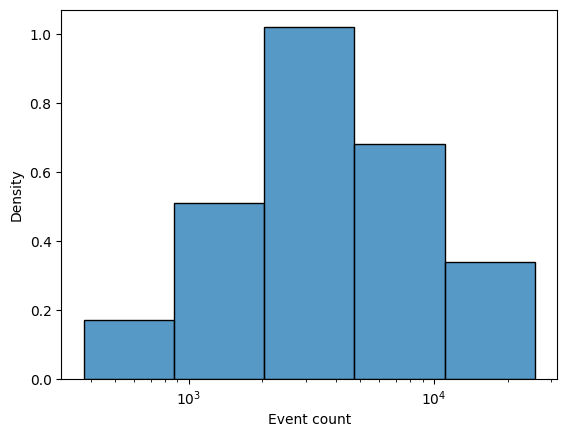

In [105]:
event_counts = df['EventLabel'].value_counts()
sns.histplot(data=event_counts, log_scale=True, stat='density')
plt.xlabel("Event count");

evt_count_avg = event_counts.values.mean()
evt_count_std = event_counts.values.std()
print(f"Event count:")
print(f"    Average={evt_count_avg}")
print(f"    Std. dev={evt_count_std}")


# Event count distribution: log-normal?

/tmp/ipykernel_4814/120193414.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=45);


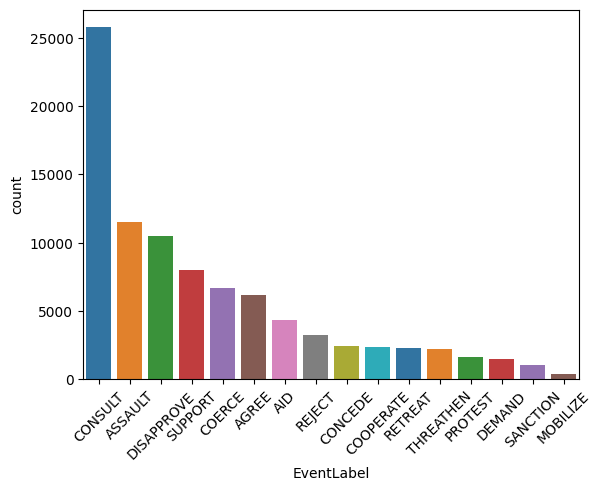

In [106]:
event_count_df = event_counts.reset_index()
plot = sns.barplot(data=event_count_df, x='EventLabel', y='count', hue='EventLabel', palette='tab10', legend=False);
plot.set_xticklabels(plot.get_xticklabels(), rotation=45);


/tmp/ipykernel_4814/3040765560.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=45);


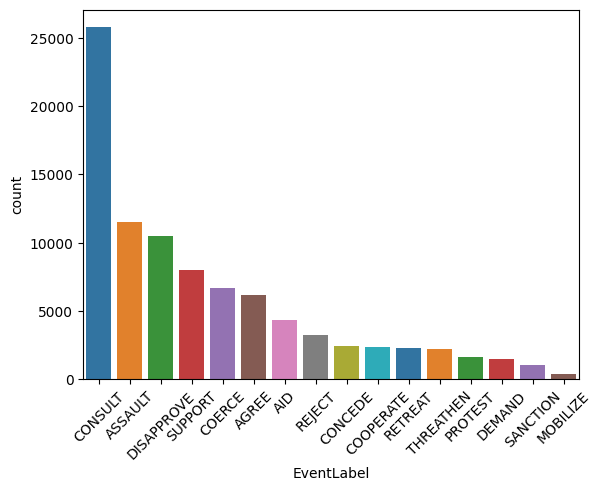

In [107]:
# Events with count >= n
n = 50
event_count_df_cutoff = event_counts[event_counts>n].reset_index()
plot = sns.barplot(data=event_count_df_cutoff, x='EventLabel', y='count', hue='EventLabel', palette='tab10', legend=False);
plot.set_xticklabels(plot.get_xticklabels(), rotation=45);


In [108]:
from datetime import datetime
df.drop('level_0', axis=1, inplace=True)
df.to_csv(f"../data/train_{datetime.now().strftime("%Y%m%d%H%M%S")}.csv", index=None)

In [109]:
# Actor1 distribution

print(df['Actor1Code'].value_counts())
print(df['Actor2Code'].value_counts())

Actor1Code
USA          26678
GOV           5462
USAGOV        3032
BUS           2842
JUD           2708
             ...  
CHRCTHHLH        1
PAKBUS           1
MNCCHN           1
USAGOVHRI        1
hut              1
Name: count, Length: 1047, dtype: int64
Actor2Code
USA          22061
GOV           4304
CVL           2535
BUS           2487
USAGOV        2437
             ...  
NGODEVAGR        1
RWAGOV           1
EDUAGR           1
LBNMED           1
EDUJUD           1
Name: count, Length: 956, dtype: int64
